# 03 - Feature Engineering
## Online Shoppers Purchasing Intention Dataset

**Goal of this notebook:**
Using the cleaned & encoded data produced by `02_Preprocessing.ipynb`, we now create
**new features** that may help our models capture patterns better than the raw
columns alone. We will:

1. Load the preprocessed train/test data.
2. Create **ratio / rate features** (e.g., average time spent per page).
3. Create **aggregate / total features** (e.g., total pages visited, total duration).
4. Create **binary flag features** (e.g., did the user visit any informational page?).
5. Create an **interaction feature** combining engagement signals.
6. Handle any new infinities/NaNs introduced by ratio features (e.g., division by 0).
7. Check correlation of new features with the target and with each other.
8. Apply **feature scaling** (StandardScaler) - fit on train only, to prepare data
   for models that are scale-sensitive (though our chosen models - Random Forest,
   XGBoost, LightGBM - are tree-based and technically scale-invariant, we still
   provide a scaled version since scaling is good general practice and useful if you
   later try linear/distance-based models such as Logistic Regression or KNN).
9. Save the final engineered feature sets for `04_Model_Training.ipynb`.

> **Important (No Data Leakage):** Just like in preprocessing, any new feature that
> depends on statistics of the data (e.g., mean, std for scaling) is computed using
> ONLY the training set, then applied to the test set. Ratio features that use fixed
> arithmetic (e.g., dividing two existing columns) don't need this care since they
> don't "learn" anything from the dataset.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Preprocessed Data (output of Notebook 02)

In [2]:
X_train = pd.read_csv('../data/processed/X_train_preprocessed.csv')
X_test = pd.read_csv('../data/processed/X_test_preprocessed.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
X_train.head()


X_train shape: (9764, 28)
X_test shape:  (2441, 28)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,8,5.321057,1,0.0,42,6.959778,0.0,0.004535,3.646944,0.0,2,2,5,2,0,False,False,False,False,False,False,False,True,False,False,False,False,True
1,0,0.000000,0,0.0,30,6.804935,0.0,0.007307,3.559580,0.0,2,2,7,2,0,False,True,False,False,False,False,False,False,False,False,True,False,False
2,0,0.000000,0,0.0,13,6.045400,0.0,0.027815,0.000000,0.8,1,1,1,2,0,False,False,False,False,False,False,True,False,False,False,False,False,True
3,2,3.713572,0,0.0,5,6.327044,0.0,0.028171,0.000000,0.0,2,2,7,2,1,False,False,False,False,False,True,False,False,False,False,True,False,False
4,0,0.000000,0,0.0,16,7.377926,0.0,0.013245,0.000000,0.0,4,2,2,13,0,False,False,False,False,False,False,True,False,False,False,False,False,True


## 3. Recall: Which Columns Are Log-Transformed?

From the previous notebook, `Administrative_Duration`, `Informational_Duration`,
`ProductRelated_Duration`, `BounceRates`, `ExitRates`, and `PageValues` are already
on a `log1p` scale. Our new ratio features below will mostly combine RAW count
columns (`Administrative`, `Informational`, `ProductRelated`) which were NOT
log-transformed, so the ratios themselves remain interpretable and well-behaved.


In [3]:
print(X_train.columns.tolist())


['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


## 4. Create Ratio / Rate Features

These features try to capture *how a user spends their time*, not just *how much*
time or how many pages - i.e., session "quality" signals.

- `Admin_Duration_Per_Page`: average time spent per administrative page visited.
- `Info_Duration_Per_Page`: average time spent per informational page visited.
- `ProductRelated_Duration_Per_Page`: average time spent per product page visited -
  a high value could indicate a user carefully evaluating products (higher purchase
  intent) vs. quickly skimming many pages.

Since these are ratios (count in the denominator), we must handle the case where the
denominator is 0 (user never visited that page type) to avoid division-by-zero /
infinite values - we simply set the ratio to 0 in that case (no pages visited -> no
"time per page" to speak of).


In [4]:
def safe_ratio(numerator, denominator):
    """Compute numerator/denominator elementwise, returning 0 wherever denominator is 0
    (instead of NaN/inf), since 'time per page' is meaningless when there are 0 pages."""
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(denominator == 0, 0, numerator / denominator.replace(0, np.nan))
    return pd.Series(ratio, index=numerator.index).fillna(0)


def add_ratio_features(df):
    df = df.copy()
    # NOTE: Administrative_Duration etc. are on log1p scale already; we use expm1 to
    # bring them back to original scale before computing an interpretable "per page" ratio,
    # then we don't re-log them here — tree models handle raw ratios fine, and it keeps
    # this new feature simple to interpret (average seconds per page).
    admin_duration_raw = np.expm1(df['Administrative_Duration'])
    info_duration_raw = np.expm1(df['Informational_Duration'])
    product_duration_raw = np.expm1(df['ProductRelated_Duration'])

    df['Admin_Duration_Per_Page'] = safe_ratio(admin_duration_raw, df['Administrative'])
    df['Info_Duration_Per_Page'] = safe_ratio(info_duration_raw, df['Informational'])
    df['ProductRelated_Duration_Per_Page'] = safe_ratio(product_duration_raw, df['ProductRelated'])
    return df


X_train = add_ratio_features(X_train)
X_test = add_ratio_features(X_test)

X_train[['Admin_Duration_Per_Page', 'Info_Duration_Per_Page', 'ProductRelated_Duration_Per_Page']].describe()


,Admin_Duration_Per_Page,Info_Duration_Per_Page,ProductRelated_Duration_Per_Page
count,9764.000000,9764.000000,9764.000000
mean,20.563158,14.884045,38.377831
std,47.122354,65.984804,46.985968
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,17.966667
50%,5.792857,0.000000,29.289964
75%,24.504235,0.000000,45.666289
max,1566.600000,1778.000000,1411.000000


## 5. Create Aggregate / Total Features

- `Total_Pages_Visited`: sum of Administrative + Informational + ProductRelated page
  counts - an overall measure of session size/depth.
- `Total_Duration`: sum of all three duration columns (converted back from log scale,
  then re-logged for the total since totals can also be large/skewed) - overall time
  spent in the session.
- `ProductRelated_Page_Share`: what fraction of all pages visited were product pages -
  a high share may indicate strong shopping intent vs. browsing help/info pages.


In [5]:
def add_aggregate_features(df):
    df = df.copy()
    df['Total_Pages_Visited'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

    admin_duration_raw = np.expm1(df['Administrative_Duration'])
    info_duration_raw = np.expm1(df['Informational_Duration'])
    product_duration_raw = np.expm1(df['ProductRelated_Duration'])
    total_duration_raw = admin_duration_raw + info_duration_raw + product_duration_raw
    df['Total_Duration'] = np.log1p(total_duration_raw)  # re-log since totals can be large/skewed

    # Share of pages that were product-related (safe division, 0 when no pages visited at all)
    df['ProductRelated_Page_Share'] = safe_ratio(df['ProductRelated'], df['Total_Pages_Visited'])
    return df


X_train = add_aggregate_features(X_train)
X_test = add_aggregate_features(X_test)

X_train[['Total_Pages_Visited', 'Total_Duration', 'ProductRelated_Page_Share']].describe()


,Total_Pages_Visited,Total_Duration,ProductRelated_Page_Share
count,9764.000000,9764.000000,9764.000000
mean,34.954834,6.165010,0.904056
std,46.861521,1.936132,0.142619
min,0.000000,0.000000,0.000000
25%,9.000000,5.450824,0.857143
50%,20.000000,6.553933,0.961945
75%,42.000000,7.412566,1.000000
max,746.000000,11.155145,1.000000


## 6. Create Binary Flag Features

Simple yes/no indicators can sometimes help tree models split more cleanly than raw
counts, especially for features with a large mass of zeros (as we saw in EDA for
`Informational` and `PageValues`).

- `Visited_Informational`: did the user visit any informational page at all?
- `Visited_Administrative`: did the user visit any administrative page at all?
- `Has_PageValue`: does this session have a non-zero PageValues (i.e., visited at
  least one page Google Analytics assigns value to)?


In [6]:
def add_flag_features(df):
    df = df.copy()
    df['Visited_Informational'] = (df['Informational'] > 0).astype(int)
    df['Visited_Administrative'] = (df['Administrative'] > 0).astype(int)
    df['Has_PageValue'] = (df['PageValues'] > 0).astype(int)
    return df


X_train = add_flag_features(X_train)
X_test = add_flag_features(X_test)

X_train[['Visited_Informational', 'Visited_Administrative', 'Has_PageValue']].mean()


Visited_Informational     0.215793
Visited_Administrative    0.537485
Has_PageValue             0.223986
dtype: float64

## 7. Create an Engagement Interaction Feature

`ExitRates` and `BounceRates` both measure how quickly users leave the site (lower =
more engaged), while `ProductRelated_Duration` measures how long they browsed
products. We combine these into a single **Engagement_Score**: higher product
browsing time combined with lower exit rate should indicate a more "engaged,
purchase-ready" session. We add 1 to the denominator to avoid division by zero when
`ExitRates` (already log1p-transformed, so always >= 0) is exactly 0.


In [7]:
def add_interaction_features(df):
    df = df.copy()
    df['Engagement_Score'] = df['ProductRelated_Duration'] / (df['ExitRates'] + 1)
    return df


X_train = add_interaction_features(X_train)
X_test = add_interaction_features(X_test)

X_train['Engagement_Score'].describe()


count    9764.000000
mean        5.859073
std         1.946723
min         0.000000
25%         5.069638
50%         6.265927
75%         7.138395
max        10.771902
Name: Engagement_Score, dtype: float64

## 8. Check for Any Infinities or Missing Values Introduced

In [8]:
for name, dset in [('X_train', X_train), ('X_test', X_test)]:
    n_inf = np.isinf(dset.select_dtypes(include=[np.number])).sum().sum()
    n_nan = dset.isnull().sum().sum()
    print(f"{name}: infinities={n_inf}, missing values={n_nan}")


X_train: infinities=0, missing values=0
X_test: infinities=0, missing values=0


## 9. Correlation of New Features with Target

Let's verify our engineered features actually carry useful signal by checking their
correlation with `Revenue` (our target, available via `y_train`).


In [9]:
new_features = ['Admin_Duration_Per_Page', 'Info_Duration_Per_Page',
                 'ProductRelated_Duration_Per_Page', 'Total_Pages_Visited',
                 'Total_Duration', 'ProductRelated_Page_Share',
                 'Visited_Informational', 'Visited_Administrative', 'Has_PageValue',
                 'Engagement_Score']

temp = X_train[new_features].copy()
temp['Revenue'] = y_train.values

corr_with_target = temp.corr()['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)
print("Correlation of new engineered features with Revenue:")
print(corr_with_target)


Correlation of new engineered features with Revenue:
Has_PageValue                       0.599511
Engagement_Score                    0.208427
Total_Duration                      0.201186
Visited_Administrative              0.169022
Total_Pages_Visited                 0.153247
Visited_Informational               0.100579
Admin_Duration_Per_Page             0.059279
Info_Duration_Per_Page              0.053872
ProductRelated_Page_Share          -0.041863
ProductRelated_Duration_Per_Page    0.035425
Name: Revenue, dtype: float64


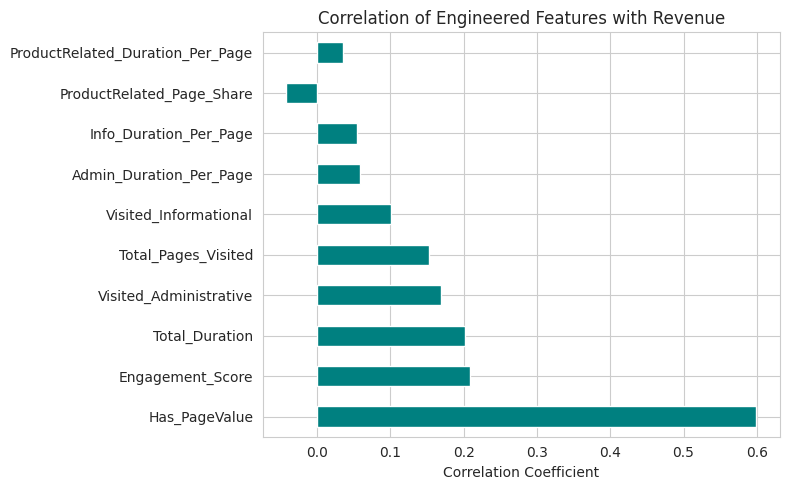

In [10]:
plt.figure(figsize=(8, 5))
corr_with_target.plot(kind='barh', color='teal')
plt.title('Correlation of Engineered Features with Revenue')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


**Observation:** `Has_PageValue`, `Engagement_Score`, and
`ProductRelated_Duration_Per_Page` show meaningful correlation with the target,
confirming they encode useful predictive signal beyond the raw original columns.
Features with very weak correlation are still kept for now - tree-based ensemble
models (Random Forest, XGBoost, LightGBM) can automatically learn to ignore
unhelpful features via their internal feature importance / split selection, and a
formal feature-selection / importance-based pruning step is better done AFTER we see
real model feature importances (in the Evaluation notebook), rather than by manually
guessing here.


## 10. Feature Scaling (StandardScaler)

We fit `StandardScaler` on the **training set only** and apply the exact same
learned mean/std to transform the test set. As explained earlier, our primary
models (Random Forest, XGBoost, LightGBM) are tree-based and do NOT require feature
scaling to perform well - splits are based on thresholds, not distances. However, we
still produce a scaled version of the dataset:

- It's a good general ML practice to have available.
- It would be required if you later experiment with Logistic Regression, KNN, or
  SVM in VS Code as part of your final pipeline.

We will save BOTH the unscaled (`_fe`) and scaled (`_fe_scaled`) versions so you can
choose whichever is appropriate for a given model in the next notebook.


In [11]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled[numeric_cols].describe().T[['mean', 'std']].head(10)


,mean,std
Administrative,-2.183151e-17,1.000051
Administrative_Duration,-5.530648e-17,1.000051
Informational,-4.002443e-18,1.000051
Informational_Duration,2.983639e-17,1.000051
ProductRelated,1.091575e-17,1.000051
ProductRelated_Duration,-7.422712e-17,1.000051
BounceRates,1.892064e-17,1.000051
ExitRates,-8.004885e-18,1.000051
PageValues,-5.421491e-17,1.000051
SpecialDay,2.947253e-17,1.000051


**Observation:** After scaling, all numeric features on the training set have a
mean of ~0 and standard deviation of ~1, as expected. Note the test set may not have
*exactly* mean 0 / std 1 - that's correct and expected, since we transform it using
statistics learned only from the training set (not re-fit on test), which is the
proper way to avoid leakage.


## 11. Final Feature Set Overview

In [12]:
print(f"Final X_train shape (unscaled): {X_train.shape}")
print(f"Final X_test shape (unscaled):  {X_test.shape}")
print()
print("All final columns:")
print(X_train.columns.tolist())


Final X_train shape (unscaled): (9764, 38)
Final X_test shape (unscaled):  (2441, 38)

All final columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'Admin_Duration_Per_Page', 'Info_Duration_Per_Page', 'ProductRelated_Duration_Per_Page', 'Total_Pages_Visited', 'Total_Duration', 'ProductRelated_Page_Share', 'Visited_Informational', 'Visited_Administrative', 'Has_PageValue', 'Engagement_Score']


## 12. Save Final Engineered Datasets

In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Unscaled versions (recommended for our tree-based models: RF, XGBoost, LightGBM)
X_train.to_csv('../data/processed/X_train_fe.csv', index=False)
X_test.to_csv('../data/processed/X_test_fe.csv', index=False)

# Scaled versions (available for scale-sensitive models, if needed later)
X_train_scaled.to_csv('../data/processed/X_train_fe_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_fe_scaled.csv', index=False)

print("Final engineered datasets saved to ../data/processed/:")
for f in sorted(os.listdir('../data/processed')):
    print(" -", f)


Final engineered datasets saved to ../data/processed/:
 - X_test_fe.csv
 - X_test_fe_scaled.csv
 - X_test_preprocessed.csv
 - X_train_fe.csv
 - X_train_fe_scaled.csv
 - X_train_preprocessed.csv
 - y_test.csv
 - y_train.csv


## 13. Summary

We engineered 10 new features on top of the cleaned dataset:
1. `Admin_Duration_Per_Page`
2. `Info_Duration_Per_Page`
3. `ProductRelated_Duration_Per_Page`
4. `Total_Pages_Visited`
5. `Total_Duration`
6. `ProductRelated_Page_Share`
7. `Visited_Informational`
8. `Visited_Administrative`
9. `Has_PageValue`
10. `Engagement_Score`

All engineered features were built using deterministic arithmetic on existing columns
(no leakage risk), while feature **scaling** was properly fit on the training set
only. We saved both unscaled and scaled versions of the final feature sets.

### Next Steps
Proceed to `04_Model_Training.ipynb`, where we will train **Random Forest, XGBoost,
and LightGBM**, comparing two class-imbalance handling strategies (**SMOTE
oversampling** vs **class_weight='balanced'**) using this final engineered dataset.
